# BERT EMBEDDINGS + MACHINE LEARNING
## BERT como extrator de features + treinamento de modelos clássicos

**Objetivo:**
1. Usar BERT (BERTimbau) para extrair embeddings de 768 dimensões
2. Treinar 5 modelos ML com esses embeddings
3. Matrizes de confusão para todos
4. LIME e SHAP para interpretabilidade
5. Comparar com TF-IDF (Notebook 4)

## 1. IMPORTAÇÕES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import re
from tqdm import tqdm
warnings.filterwarnings('ignore')

# BERT
import torch
from transformers import BertTokenizer, BertModel

# ML
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

# Interpretabilidade
from lime.lime_tabular import LimeTabularExplainer
import shap

# Salvar
import joblib

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Bibliotecas importadas!")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

✅ Bibliotecas importadas!
PyTorch: 2.0.1+cpu
CUDA: False


## 2. CARREGAR DADOS

In [3]:
df = pd.read_csv('../data/processed/reviews_balanceadas.csv')

print("="*80)
print("📊 DADOS CARREGADOS")
print("="*80)
print(f"Total: {len(df):,} reviews")
print(f"\nDistribuição:")
print(df['sentimento'].value_counts())

# Mapear sentimentos
sentimento_map = {'Positivo': 2, 'Neutro': 1, 'Negativo': 0}
df['label'] = df['sentimento'].map(sentimento_map)

📊 DADOS CARREGADOS
Total: 3,789 reviews

Distribuição:
sentimento
Negativo    1263
Neutro      1263
Positivo    1263
Name: count, dtype: int64


## 3. PRÉ-PROCESSAMENTO MÍNIMO

BERT precisa de texto original (apenas limpeza básica).

In [4]:
def preprocessar_bert(texto):
    texto = str(texto).lower().strip()
    texto = re.sub(r'http\S+|www\S+', '', texto)
    texto = re.sub(r'@\w+|#\w+', '', texto)
    texto = re.sub(r'[^a-záàâãéèêíïóôõöúçñ\s.,!?]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

print("🔄 Aplicando pré-processamento...")
df['texto_limpo'] = df['texto'].apply(preprocessar_bert)
print("✅ Concluído!")

🔄 Aplicando pré-processamento...
✅ Concluído!


## 4. CARREGAR BERT (BERTimbau)

In [5]:
MODEL_NAME = 'neuralmind/bert-base-portuguese-cased'

print("="*80)
print("🤖 CARREGANDO BERT PARA EXTRAÇÃO DE EMBEDDINGS")
print("="*80)
print(f"Modelo: {MODEL_NAME}")
print("\n⏳ Carregando...")

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
bert_model = BertModel.from_pretrained(MODEL_NAME)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
bert_model = bert_model.to(device)
bert_model.eval()

print(f"\n✅ BERT carregado!")
print(f"Device: {device}")

🤖 CARREGANDO BERT PARA EXTRAÇÃO DE EMBEDDINGS
Modelo: neuralmind/bert-base-portuguese-cased

⏳ Carregando...


vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of the model checkpoint at neuralmind/bert-base-portuguese-cased were not used when initializing BertModel: ['cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.predictions.decoder.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).



✅ BERT carregado!
Device: cpu


## 5. EXTRAIR EMBEDDINGS

Cada texto vira um vetor de 768 dimensões (token [CLS]).

In [6]:
def get_bert_embedding(text, tokenizer, model, device, max_length=128):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, 
                       padding='max_length', max_length=max_length)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()
    return cls_embedding[0]

print("🔄 Extraindo embeddings...")
print("⏱️  Pode demorar 10-40 min (depende de CPU/GPU)\n")

embeddings = []
for text in tqdm(df['texto_limpo'].tolist(), desc="Processando"):
    emb = get_bert_embedding(text, tokenizer, bert_model, device)
    embeddings.append(emb)

X_embeddings = np.array(embeddings)
y = df['label'].values

print(f"\n✅ Embeddings extraídos!")
print(f"Shape: {X_embeddings.shape}")
print(f"  - {X_embeddings.shape[0]:,} amostras")
print(f"  - {X_embeddings.shape[1]} dimensões (features BERT)")

# Salvar embeddings
os.makedirs('../results/models', exist_ok=True)
np.save('../results/models/bert_embeddings.npy', X_embeddings)
print("\n💾 Embeddings salvos: ../results/models/bert_embeddings.npy")

🔄 Extraindo embeddings...
⏱️  Pode demorar 10-40 min (depende de CPU/GPU)



Processando: 100%|██████████| 3789/3789 [21:57<00:00,  2.88it/s]


✅ Embeddings extraídos!
Shape: (3789, 768)
  - 3,789 amostras
  - 768 dimensões (features BERT)

💾 Embeddings salvos: ../results/models/bert_embeddings.npy


## 6. DIVISÃO TREINO/TESTE

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings, y, test_size=0.2, random_state=42, stratify=y
)

print("="*80)
print("📊 DIVISÃO DOS DADOS")
print("="*80)
print(f"Treino: {len(X_train):,} amostras")
print(f"Teste:  {len(X_test):,} amostras")

📊 DIVISÃO DOS DADOS
Treino: 3,031 amostras
Teste:  758 amostras


## 7. TREINAR 5 MODELOS ML

In [8]:
def treinar_avaliar(nome, modelo, X_train, X_test, y_train, y_test):
    print(f"\n{'='*80}")
    print(f"🤖 {nome}")
    print(f"{'='*80}")
    
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    print(f"\n📊 MÉTRICAS:")
    print(f"   Acurácia:  {acc:.4f}")
    print(f"   Precisão:  {prec:.4f}")
    print(f"   Recall:    {rec:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    
    # Salvar
    joblib.dump(modelo, f"../results/models/{nome.lower().replace(' ', '_')}_bert.pkl")
    
    return {'nome': nome, 'modelo': modelo, 'acuracia': acc, 'precisao': prec, 
            'recall': rec, 'f1': f1, 'predicoes': y_pred, 'matriz_confusao': cm}

In [10]:
# Treinar todos
modelos = {
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(kernel='linear', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

resultados = []
for nome, modelo in modelos.items():
    resultado = treinar_avaliar(nome, modelo, X_train, X_test, y_train, y_test)
    resultados.append(resultado)


🤖 Naive Bayes

📊 MÉTRICAS:
   Acurácia:  0.6240
   Precisão:  0.6226
   Recall:    0.6240
   F1-Score:  0.6202

🤖 SVM

📊 MÉTRICAS:
   Acurácia:  0.6583
   Precisão:  0.6539
   Recall:    0.6583
   F1-Score:  0.6543

🤖 Random Forest

📊 MÉTRICAS:
   Acurácia:  0.6596
   Precisão:  0.6550
   Recall:    0.6596
   F1-Score:  0.6565

🤖 Regressão Logística

📊 MÉTRICAS:
   Acurácia:  0.6821
   Precisão:  0.6763
   Recall:    0.6821
   F1-Score:  0.6774

🤖 Gradient Boosting

📊 MÉTRICAS:
   Acurácia:  0.7071
   Precisão:  0.7041
   Recall:    0.7071
   F1-Score:  0.7044


## 8. COMPARAÇÃO DE RESULTADOS

In [11]:
df_res = pd.DataFrame([{k: r[k] for k in ['nome', 'acuracia', 'precisao', 'recall', 'f1']} 
                        for r in resultados])
df_res = df_res.sort_values('f1', ascending=False).reset_index(drop=True)

print("="*80)
print("📊 COMPARAÇÃO - BERT EMBEDDINGS + ML")
print("="*80)
display(df_res.style.background_gradient(cmap='RdYlGn', subset=['f1']))

# Salvar
os.makedirs('../results/metrics', exist_ok=True)
df_res.to_csv('../results/metrics/06_metricas_bert_embeddings.csv', index=False)
print(f"\n💾 Métricas salvas!")

📊 COMPARAÇÃO - BERT EMBEDDINGS + ML


,nome,acuracia,precisao,recall,f1
0,Gradient Boosting,0.707124,0.704081,0.707124,0.704408
1,Regressão Logística,0.682058,0.676349,0.682058,0.677439
2,Random Forest,0.659631,0.655017,0.659631,0.656499
3,SVM,0.658311,0.653881,0.658311,0.654323
4,Naive Bayes,0.624011,0.622569,0.624011,0.620169



💾 Métricas salvas!


##  9. MATRIZES DE CONFUSÃO

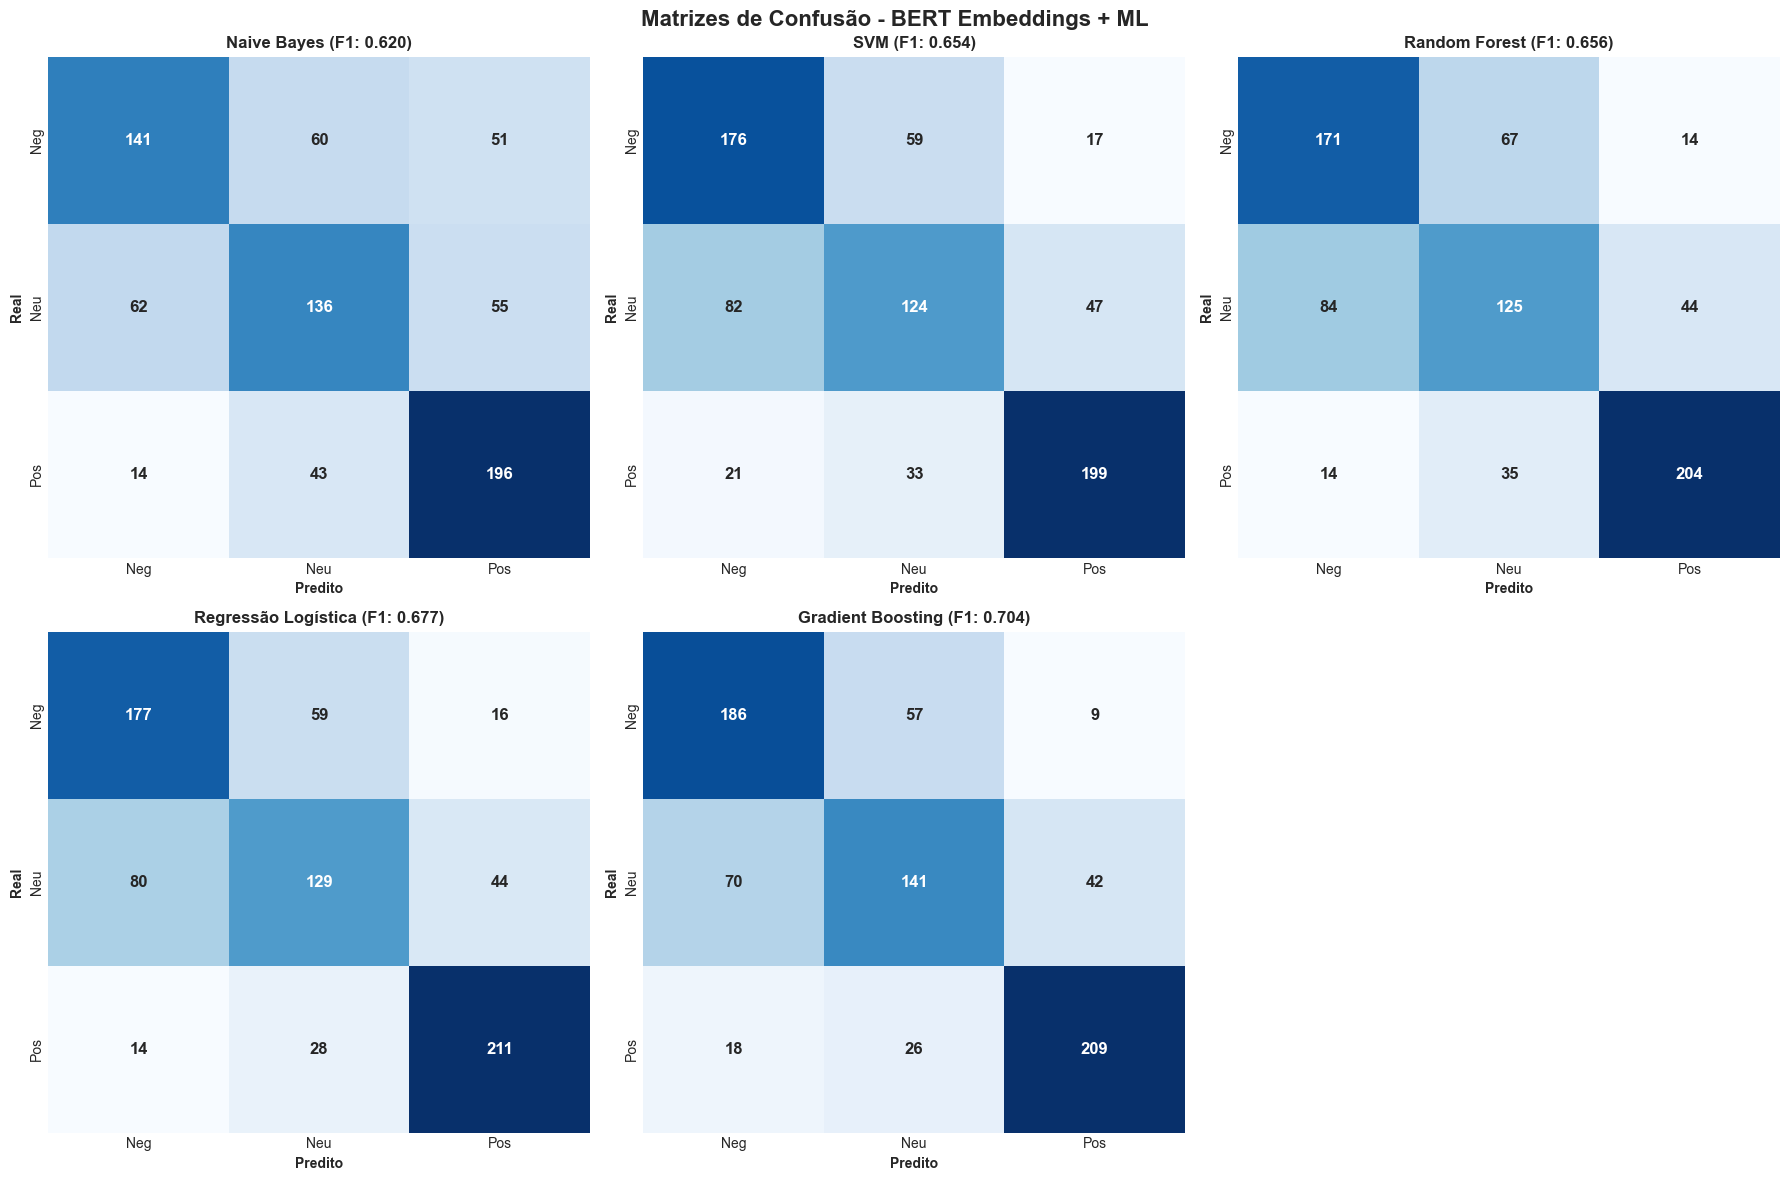

💾 Matrizes salvas!


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, res in enumerate(resultados):
    sns.heatmap(res['matriz_confusao'], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'],
                ax=axes[idx], cbar=False, annot_kws={'size': 12, 'weight': 'bold'})
    axes[idx].set_title(f"{res['nome']} (F1: {res['f1']:.3f})", fontweight='bold')
    axes[idx].set_ylabel('Real', fontweight='bold')
    axes[idx].set_xlabel('Predito', fontweight='bold')

fig.delaxes(axes[5])
plt.suptitle('Matrizes de Confusão - BERT Embeddings + ML', fontsize=16, fontweight='bold')
plt.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/06_matrizes_confusao_bert.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Matrizes salvas!")

## 10. LIME (Tabular)

🔍 LIME - EXPLICABILIDADE DO MELHOR MODELO

🏆 Modelo selecionado: Gradient Boosting
📊 F1-Score: 0.7044

💡 LIME vai explicar COMO o modelo toma decisões
   mostrando quais dimensões BERT influenciam mais.

📝 Exemplo selecionado (índice 5):
   Real: Negativo
   Predito: Neutro
   ❌ ERRO

🔄 Gerando explicação LIME...
⏱️  Isso pode demorar 30-60 segundos...

✅ Explicação gerada!

🔍 Top 10 dimensões BERT mais influentes:
   📈 bert_dim_482 <= -0.03 → +0.0300
   📉 0.24 < bert_dim_328 <= 0.42 → -0.0264
   📈 bert_dim_203 > -0.03 → +0.0261
   📉 bert_dim_514 <= -0.25 → -0.0246
   📈 -0.23 < bert_dim_230 <= -0.05 → +0.0231
   📈 bert_dim_69 <= -0.07 → +0.0222
   📈 bert_dim_115 > 0.28 → +0.0215
   📈 0.18 < bert_dim_169 <= 0.34 → +0.0211
   📈 bert_dim_534 <= -0.11 → +0.0208
   📈 bert_dim_595 <= 0.11 → +0.0157


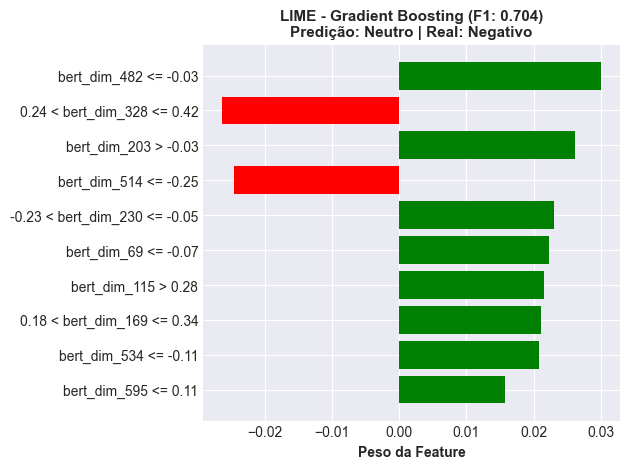


💾 LIME salvo: ../results/figures/06_lime_bert.png


In [17]:
## 🔍 10. LIME (Tabular)

# IMPORTANTE: Ordenar resultados por F1-Score para pegar o melhor
resultados_ordenados = sorted(resultados, key=lambda x: x['f1'], reverse=True)

# Usar melhor modelo (maior F1)
melhor = resultados_ordenados[0]
modelo = melhor['modelo']

print("="*80)
print(f"🔍 LIME - EXPLICABILIDADE DO MELHOR MODELO")
print("="*80)
print(f"\n🏆 Modelo selecionado: {melhor['nome']}")
print(f"📊 F1-Score: {melhor['f1']:.4f}")
print(f"\n💡 LIME vai explicar COMO o modelo toma decisões")
print(f"   mostrando quais dimensões BERT influenciam mais.\n")

# Criar explainer
explainer = LimeTabularExplainer(
    X_train, 
    mode='classification',
    class_names=['Negativo', 'Neutro', 'Positivo'],
    feature_names=[f'bert_dim_{i}' for i in range(768)]
)

# Selecionar exemplo para explicar
idx = 5
classe_real = ['Negativo', 'Neutro', 'Positivo'][y_test[idx]]
predicao = modelo.predict([X_test[idx]])[0]
classe_pred = ['Negativo', 'Neutro', 'Positivo'][predicao]

print(f"📝 Exemplo selecionado (índice {idx}):")
print(f"   Real: {classe_real}")
print(f"   Predito: {classe_pred}")
print(f"   {'✅ ACERTO' if classe_real == classe_pred else '❌ ERRO'}\n")

print("🔄 Gerando explicação LIME...")
print("⏱️  Isso pode demorar 30-60 segundos...\n")

# Gerar explicação
exp = explainer.explain_instance(
    X_test[idx], 
    modelo.predict_proba, 
    num_features=10
)

print("✅ Explicação gerada!")
print("\n🔍 Top 10 dimensões BERT mais influentes:")
print("="*60)
for feature, weight in exp.as_list():
    sinal = "📈" if weight > 0 else "📉"
    print(f"   {sinal} {feature:15s} → {weight:+.4f}")

# Visualizar
fig = exp.as_pyplot_figure()
plt.title(f'LIME - {melhor["nome"]} (F1: {melhor["f1"]:.3f})\n'
          f'Predição: {classe_pred} | Real: {classe_real}', 
          fontweight='bold', fontsize=11)
plt.xlabel('Peso da Feature', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/06_lime_bert.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 LIME salvo: ../results/figures/06_lime_bert.png")

## 12. COMPARAÇÃO COM TF-IDF

📊 COMPARAÇÃO: TF-IDF vs BERT EMBEDDINGS


,nome,Abordagem,f1
0,Gradient Boosting,BERT Embeddings,0.704408
1,Regressão Logística,BERT Embeddings,0.677439
2,Random Forest,BERT Embeddings,0.656499
3,SVM,BERT Embeddings,0.654323
0,Naive Bayes,TF-IDF,0.648923
1,Regressão Logística,TF-IDF,0.648440
2,SVM,TF-IDF,0.645310
4,Naive Bayes,BERT Embeddings,0.620169
3,Random Forest,TF-IDF,0.614256
4,Gradient Boosting,TF-IDF,0.609000


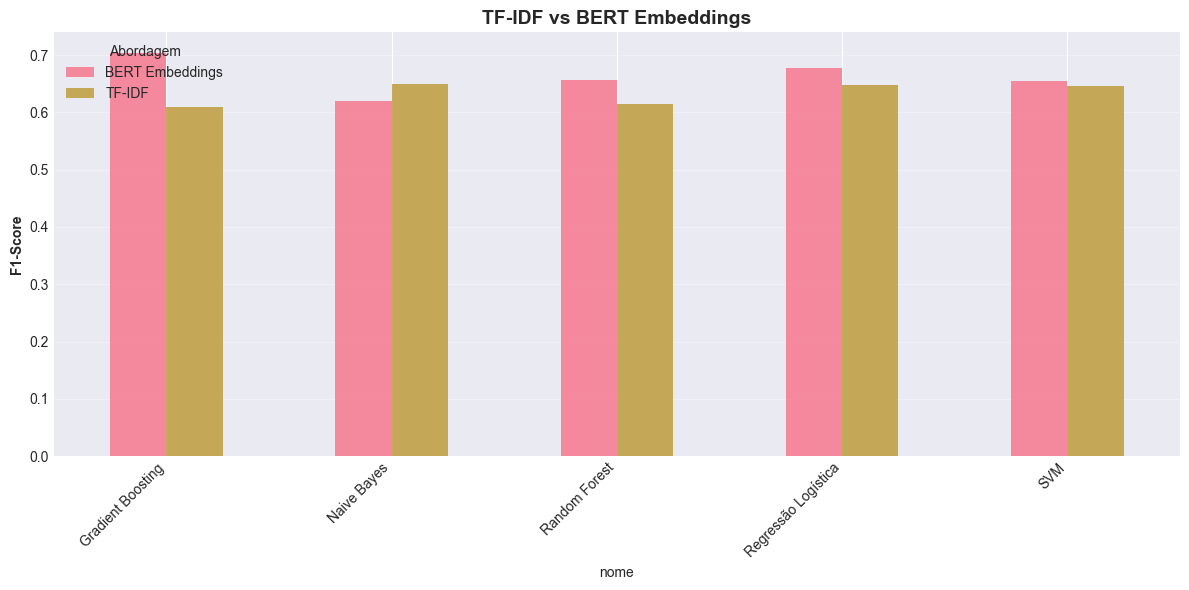

💾 Comparação salva!


In [14]:
# Carregar resultados TF-IDF (Notebook 4)
try:
    df_tfidf = pd.read_csv('../results/metrics/04_metricas_tfidf.csv')
    df_tfidf['Abordagem'] = 'TF-IDF'
    df_res['Abordagem'] = 'BERT Embeddings'
    
    df_comp = pd.concat([
        df_tfidf.rename(columns={'Modelo': 'nome', 'Acurácia': 'acuracia', 
                                  'Precisão': 'precisao', 'Recall': 'recall', 'F1-Score': 'f1'}),
        df_res
    ])
    
    print("="*80)
    print("📊 COMPARAÇÃO: TF-IDF vs BERT EMBEDDINGS")
    print("="*80)
    display(df_comp[['nome', 'Abordagem', 'f1']].sort_values('f1', ascending=False))
    
    # Gráfico
    fig, ax = plt.subplots(figsize=(12, 6))
    df_pivot = df_comp.pivot(index='nome', columns='Abordagem', values='f1')
    df_pivot.plot(kind='bar', ax=ax, alpha=0.8)
    ax.set_ylabel('F1-Score', fontweight='bold')
    ax.set_title('TF-IDF vs BERT Embeddings', fontsize=14, fontweight='bold')
    ax.legend(title='Abordagem')
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../results/figures/06_comparacao_tfidf_bert.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("💾 Comparação salva!")
except:
    print("⚠️  Notebook 4 não executado ainda")

## 13. RESUMO

In [15]:
print("="*80)
print("📋 RESUMO NOTEBOOK 6")
print("="*80)
print(f"✅ BERT extraiu embeddings de 768 dimensões")
print(f"✅ 5 modelos ML treinados")
print(f"✅ Melhor: {df_res.iloc[0]['nome']} (F1: {df_res.iloc[0]['f1']:.4f})")
print(f"\n📁 Arquivos:")
print(f"   • ../results/models/bert_embeddings.npy")
print(f"   • ../results/models/*_bert.pkl (5 modelos)")
print(f"   • ../results/metrics/06_metricas_bert_embeddings.csv")
print(f"   • ../results/figures/06_*.png")
print(f"\n➡️  Próximo: Notebook 7 - BERT Fine-Tuning")

📋 RESUMO NOTEBOOK 6
✅ BERT extraiu embeddings de 768 dimensões
✅ 5 modelos ML treinados
✅ Melhor: Gradient Boosting (F1: 0.7044)

📁 Arquivos:
   • ../results/models/bert_embeddings.npy
   • ../results/models/*_bert.pkl (5 modelos)
   • ../results/metrics/06_metricas_bert_embeddings.csv
   • ../results/figures/06_*.png

➡️  Próximo: Notebook 7 - BERT Fine-Tuning
